# Comparando Regressão Logística, Árvore de Decisão e Random Forest

## `Titanic Dataset`

Neste notebook, comparamos três modelos de classificação:

- **Regressão Logística**
- **Árvore de Decisão**
- **Random Forest**

O objetivo é prever a sobrevivência de passageiros do Titanic com base em variáveis como sexo, idade, classe, tarifa e quantidade de familiares a bordo.

A proposta didática é observar como cada modelo lida com o mesmo problema:

- a **Regressão Logística** como modelo linear de referência;
- a **Árvore de Decisão** como modelo baseado em regras;
- a **Random Forest** como um conjunto de várias árvores, treinadas com amostras e divisões aleatórias.


## Importação de libs

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)


## Carregamento dos dados

In [3]:
# Carregar o dataset Titanic diretamente do seaborn
df = sns.load_dataset('titanic')

# Visualizar as primeiras linhas
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
df['survived'].value_counts(normalize=True)

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [4]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

## Seleção de features

Para simplificação, vamos **descartar variáveis redundantes** ou com muitos valores ausentes neste primeiro modelo (`deck`, `who`, `adult_male`, `embark_town`, `class`, `alive`).

In [5]:
# Variáveis numéricas
num_features = ["age", "sibsp", "parch", "fare"]

# Variáveis categóricas
cat_features = ["pclass", "sex", "embarked", "alone"]

print("Variáveis numéricas:", num_features)
print("Variáveis categóricas:", cat_features)

# Criar novo DataFrame apenas com as variáveis escolhidas
df_model = df[num_features + cat_features].copy()

# Exibe amostra
df_model.head()

Variáveis numéricas: ['age', 'sibsp', 'parch', 'fare']
Variáveis categóricas: ['pclass', 'sex', 'embarked', 'alone']


,age,sibsp,parch,fare,pclass,sex,embarked,alone
0,22.0,1,0,7.2500,3,male,S,False
1,38.0,1,0,71.2833,1,female,C,False
2,26.0,0,0,7.9250,3,female,S,True
3,35.0,1,0,53.1000,1,female,S,False
4,35.0,0,0,8.0500,3,male,S,True


## Divisão em treino e teste

Para avaliar o modelo de forma justa, separamos os dados em **treino** e **teste**.  
- Usaremos `train_test_split` com **estratificação por `survived`** para manter a proporção de classes nos dois conjuntos.  
- Definimos um `random_state` para reprodutibilidade.  
- Mantemos o `df_model` apenas com as **features** e usamos `y = df["survived"]` como **target**.

In [6]:
# X = features selecionadas; y = alvo (survived)
X = df_model.copy()
y = df["survived"].astype(int)

# Split estratificado (ex.: 75% treino, 25% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Checagem rápida dos tamanhos e balanceamento
# Exibir resultados de forma mais clara
print("=== Divisão dos Dados ===")
print(f"Tamanho do treino: {X_train.shape[0]} amostras, {X_train.shape[1]} variáveis")
print(f"Tamanho do teste : {X_test.shape[0]} amostras, {X_test.shape[1]} variáveis\n")

print("=== Proporção de classes no treino ===")
for cls, prop in y_train.value_counts(normalize=True).round(3).items():
    print(f"Classe {cls}: {prop:.1%}")

print("\n=== Proporção de classes no teste ===")
for cls, prop in y_test.value_counts(normalize=True).round(3).items():
    print(f"Classe {cls}: {prop:.1%}")

=== Divisão dos Dados ===
Tamanho do treino: 668 amostras, 8 variáveis
Tamanho do teste : 223 amostras, 8 variáveis

=== Proporção de classes no treino ===
Classe 0: 61.7%
Classe 1: 38.3%

=== Proporção de classes no teste ===
Classe 0: 61.4%
Classe 1: 38.6%


In [9]:
X_train.head()

,age,sibsp,parch,fare,pclass,sex,embarked,alone
486,35.0,1,0,90.000,1,female,S,False
238,19.0,0,0,10.500,2,male,S,True
722,34.0,0,0,13.000,2,male,S,True
184,4.0,0,2,22.025,3,female,S,False
56,21.0,0,0,10.500,2,female,S,True


### Treinamento dos modelos com Pipeline

Para treinar os classificadores, vamos utilizar **Regressão Logística**, **Árvore de Decisão** e **Random Forest**.

Antes do treinamento, precisamos transformar os dados para que os modelos consigam utilizá-los corretamente:

> **Regressão Logística:**
> - usa padronização nas variáveis numéricas, pois o modelo é sensível à escala dos dados;
> - usa codificação *One-Hot Encoding* nas variáveis categóricas.

> **Árvore de Decisão e Random Forest:**
> - não precisam de padronização das variáveis numéricas;
> - também precisam transformar variáveis categóricas em valores numéricos;
> - podem lidar melhor com relações não lineares e interações entre variáveis.

A ideia é manter o mesmo conjunto de treino e teste para todos os modelos, tornando a comparação mais justa.


In [10]:
# Pré-processamento numérico: imputação de medianas
num_imputer = SimpleImputer(strategy="median")

# Pré-processamento numérico para Regressão Logística
num_transformer_reg = Pipeline(steps=[
    ("imputer", num_imputer),
    ("scaler", StandardScaler())
])

# Pré-processamento numérico para Árvore de Decisão
num_transformer_tree = Pipeline(steps=[
    ("imputer", num_imputer)
])

In [11]:
# Pré-processamento categórico: imputação do mais frequente + OneHot
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [12]:
# ColumnTransformer para a Regressão Logística
preprocessor_reg = ColumnTransformer(
    transformers=[
        ("num", num_transformer_reg, num_features),
        ("cat", cat_transformer, cat_features)
    ]
)

# Modelo: Regressão Logística
logreg = LogisticRegression(max_iter=1000, random_state=42)

# Pipeline completo: pré-processamento + modelo
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor_reg),
    ("classifier", logreg)
])

log_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [13]:
# ColumnTransformer para a Árvore de Decisão
preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", num_transformer_tree, num_features),
        ("cat", cat_transformer, cat_features)
    ]
)

# Modelo: Árvore de Decisão
tree = DecisionTreeClassifier(random_state=42)

# Pipeline completo: pré-processamento + modelo
tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("classifier", tree)
])

tree_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Modelo 3: Random Forest

A **Random Forest** combina várias árvores de decisão. Cada árvore é treinada com uma amostra aleatória dos dados, criada com reposição, e considera subconjuntos aleatórios de variáveis durante as divisões.

Neste exemplo, vamos usar:

- `n_estimators=100`: quantidade de árvores na floresta;
- `max_depth=3`: limita a profundidade das árvores, reduzindo o risco de overfitting;
- `oob_score=True`: calcula uma estimativa de desempenho usando amostras *out-of-bag*;
- `random_state=42`: garante reprodutibilidade.


In [28]:
# Modelo: Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=42,
    oob_score=True,
    n_jobs=-1
)

# Pipeline completo: pré-processamento + modelo
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("classifier", rf)
])

rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
print("Modelo Random Forest treinado.")
print("OOB score:", round(rf_model.named_steps["classifier"].oob_score_, 3))

Modelo Random Forest treinado.
OOB score: 0.796


## Avaliação dos modelos

Depois do treinamento, avaliamos o desempenho dos classificadores nos **dados de teste**.

Nesta primeira avaliação, usamos o limiar padrão de `0.5` para decidir se o passageiro sobreviveu (`1`) ou não sobreviveu (`0`).

Métricas principais:

- **Acurácia**: proporção total de acertos;
- **Precisão**: entre os casos previstos como sobreviventes, quantos realmente sobreviveram;
- **Recall**: entre os passageiros que realmente sobreviveram, quantos o modelo conseguiu identificar;
- **F1-score**: média harmônica entre precisão e recall.


In [30]:
# Previsões no conjunto de teste
y_pred_log = log_model.predict(X_test)
y_pred_tree = tree_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)


In [31]:
# Função auxiliar para calcular as principais métricas

def avaliar_modelo(nome, y_true, y_pred):
    return {
        "Modelo": nome,
        "Acurácia": accuracy_score(y_true, y_pred),
        "Precisão": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

resultados = pd.DataFrame([
    avaliar_modelo("Regressão Logística", y_test, y_pred_log),
    avaliar_modelo("Árvore de Decisão", y_test, y_pred_tree),
    avaliar_modelo("Random Forest", y_test, y_pred_rf)
])

resultados_formatados = resultados.copy()
for col in ["Acurácia", "Precisão", "Recall", "F1-score"]:
    resultados_formatados[col] = resultados_formatados[col].round(3)

resultados_formatados


,Modelo,Acurácia,Precisão,Recall,F1-score
0,Regressão Logística,0.785,0.732,0.698,0.714
1,Árvore de Decisão,0.726,0.640,0.663,0.651
2,Random Forest,0.789,0.775,0.640,0.701


	Modelo	Acurácia	Precisão	Recall	F1-score 

0	Regressão Logística	0.785	0.732	0.698	0.714

1	Árvore de Decisão	0.726	0.640	0.663	0.651

2	Random Forest	0.803	0.850	0.593	0.699

### Relatórios de classificação

A seguir, observamos o relatório completo para cada modelo. Ele permite analisar o desempenho por classe:

- classe `0`: passageiro não sobreviveu;
- classe `1`: passageiro sobreviveu.


In [19]:
print("=== Regressão Logística ===")
print(classification_report(y_test, y_pred_log, digits=3))

print("\n=== Árvore de Decisão ===")
print(classification_report(y_test, y_pred_tree, digits=3))

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, digits=3))


=== Regressão Logística ===
              precision    recall  f1-score   support

           0      0.816     0.839     0.827       137
           1      0.732     0.698     0.714        86

    accuracy                          0.785       223
   macro avg      0.774     0.769     0.771       223
weighted avg      0.783     0.785     0.784       223


=== Árvore de Decisão ===
              precision    recall  f1-score   support

           0      0.784     0.766     0.775       137
           1      0.640     0.663     0.651        86

    accuracy                          0.726       223
   macro avg      0.712     0.715     0.713       223
weighted avg      0.728     0.726     0.727       223


=== Random Forest ===
              precision    recall  f1-score   support

           0      0.783     0.898     0.837       137
           1      0.788     0.605     0.684        86

    accuracy                          0.785       223
   macro avg      0.786     0.751     0.760       

### Visualização comparativa das métricas

O gráfico abaixo facilita a comparação entre os três modelos. Em muitos casos, a Random Forest melhora a estabilidade em relação a uma única árvore de decisão, pois combina várias árvores diferentes.


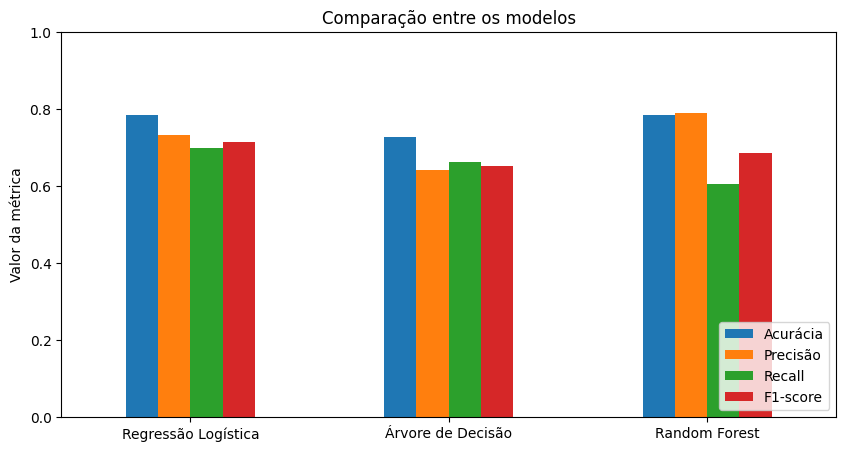

In [20]:
resultados_plot = resultados.set_index("Modelo")

ax = resultados_plot.plot(kind="bar", figsize=(10, 5))
ax.set_title("Comparação entre os modelos")
ax.set_ylabel("Valor da métrica")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.show()


### Matrizes de confusão

As matrizes de confusão ajudam a enxergar quais tipos de erro cada modelo comete.

Para este problema:

- **Verdadeiro Negativo:** o modelo previu corretamente que o passageiro não sobreviveu;
- **Verdadeiro Positivo:** o modelo previu corretamente que o passageiro sobreviveu;
- **Falso Positivo:** o modelo previu sobrevivência, mas o passageiro não sobreviveu;
- **Falso Negativo:** o modelo previu não sobrevivência, mas o passageiro sobreviveu.


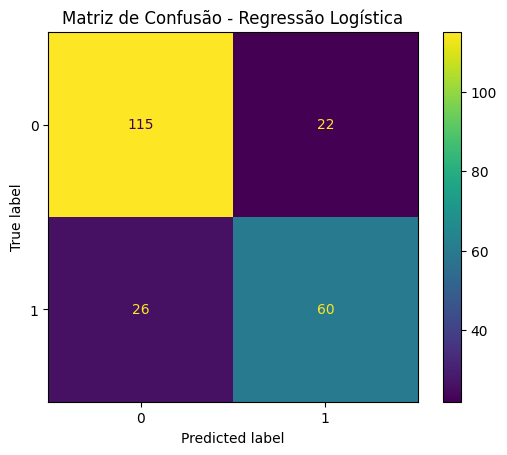

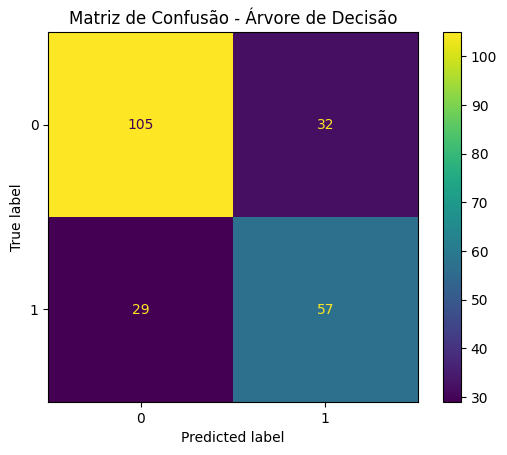

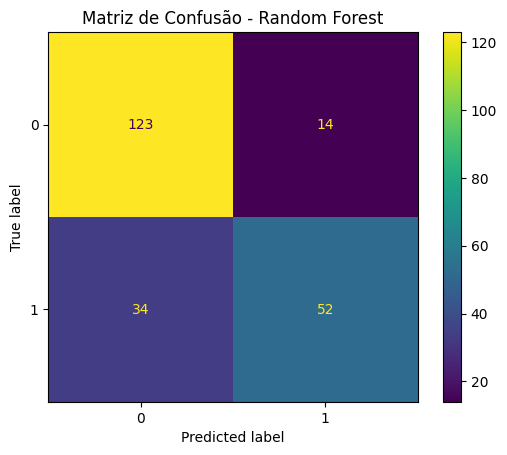

In [21]:
modelos = [
    ("Regressão Logística", log_model),
    ("Árvore de Decisão", tree_model),
    ("Random Forest", rf_model)
]

for nome, modelo in modelos:
    ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test)
    plt.title(f"Matriz de Confusão - {nome}")
    plt.show()


## Importância das variáveis na Random Forest

Uma vantagem prática da Random Forest é que podemos observar quais variáveis foram mais relevantes para as decisões do conjunto de árvores.

Como usamos `OneHotEncoder`, algumas variáveis categóricas são transformadas em várias colunas. Por isso, primeiro recuperamos os nomes das variáveis após o pré-processamento.


In [22]:
# Recuperar os nomes das variáveis após o pré-processamento
preprocessor = rf_model.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()

importancias = rf_model.named_steps["classifier"].feature_importances_

importancias_df = pd.DataFrame({
    "Variável": feature_names,
    "Importância": importancias
}).sort_values("Importância", ascending=False)

importancias_df.head(10)


,Variável,Importância
7,cat__sex_female,0.303052
8,cat__sex_male,0.250229
6,cat__pclass_3,0.108119
3,num__fare,0.102388
4,cat__pclass_1,0.068562
0,num__age,0.059770
13,cat__alone_True,0.019556
1,num__sibsp,0.019366
2,num__parch,0.015268
9,cat__embarked_C,0.015193


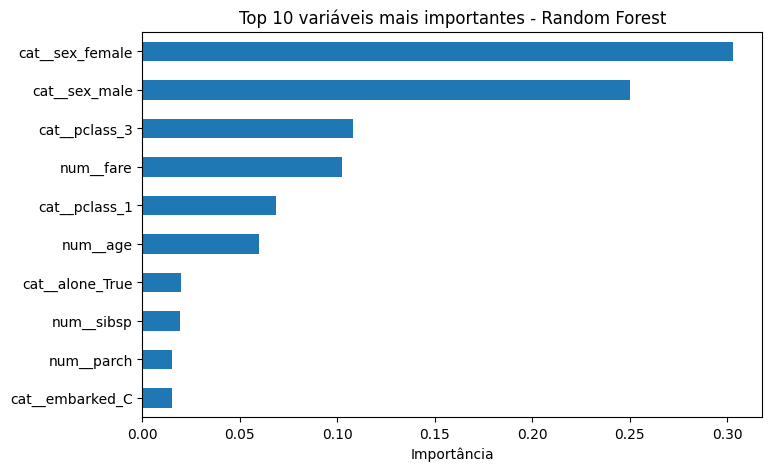

In [23]:
importancias_df.head(10).sort_values("Importância").plot(
    kind="barh",
    x="Variável",
    y="Importância",
    legend=False,
    figsize=(8, 5)
)
plt.title("Top 10 variáveis mais importantes - Random Forest")
plt.xlabel("Importância")
plt.ylabel("")
plt.show()


## Análise comparativa

A comparação entre os três modelos permite discutir pontos importantes:

### Regressão Logística

A Regressão Logística é um bom modelo de referência para classificação binária. Ela é mais simples, mais interpretável e tende a funcionar bem quando há uma relação aproximadamente linear entre as variáveis e a probabilidade da classe positiva.

### Árvore de Decisão

A Árvore de Decisão é intuitiva e fácil de explicar, pois funciona como uma sequência de perguntas. Porém, uma árvore única pode se ajustar demais aos dados de treino, especialmente quando cresce sem restrições.

### Random Forest

A Random Forest reduz parte da instabilidade de uma árvore única. Em vez de depender de uma única árvore, ela combina várias árvores treinadas de maneiras diferentes. Isso costuma melhorar a capacidade de generalização.

Neste notebook, a Random Forest deve ser analisada principalmente como uma evolução natural da Árvore de Decisão: ela mantém a ideia de decisões baseadas em regras, mas usa um conjunto de árvores para tornar as previsões mais robustas.


## Conclusão

Neste notebook, comparamos três abordagens para classificação binária usando o mesmo conjunto de dados, a mesma divisão de treino e teste e o mesmo pré-processamento básico.

A principal conclusão didática é que:

- a **Regressão Logística** é um modelo simples e forte como referência;
- a **Árvore de Decisão** é interpretável, mas pode ser instável;
- a **Random Forest** combina várias árvores para produzir previsões mais robustas.

Na próxima etapa, podemos explorar ajustes de hiperparâmetros da Random Forest, como `n_estimators`, `max_depth`, `max_features`, `min_samples_split` e `min_samples_leaf`.
